<h1 align="center"><b>Homework Assignment 3 (100 points total)</b></h1>
<h3 align="center"><b>Assigned at the start of Module 6</b></h3>
<h3 align="center"><b>Due at the end of Module 8</b></h3><br>

#### Author: Robert Feconda
#### email: rfecond1@jh.edu

# Q1 — Solving Einstein’s Riddle as a CSP

## 35 points total

**Einstein’s Riddle:**

There are **5 houses in a row**, each with a different color. Each house has an owner of a different nationality, a pet, a drink, and a cigar brand. The following clues apply:

1. The Brit lives in the red house.  
2. The Swede keeps dogs as pets.  
3. The Dane drinks tea.  
4. The green house is immediately to the left of the white house.  
5. The green house’s owner drinks coffee.  
6. The person who smokes Pall Mall rears birds.  
7. The owner of the yellow house smokes Dunhill.  
8. The man living in the center house drinks milk.  
9. The Norwegian lives in the first house.  
10. The man who smokes Blends lives next to the one who keeps cats.  
11. The man who keeps horses lives next to the man who smokes Dunhill.  
12. The man who smokes Blue Master drinks beer.  
13. The German smokes Prince.  
14. The Norwegian lives next to the blue house.  
15. The man who smokes Blends has a neighbor who drinks water.  

**Question**: Who owns the fish?

---

### [15 points] Part A – Coding (Implementation)

1. Model Einstein’s Riddle as a CSP using **OR-Tools CP-SAT**.  
   - **Variables**: House positions (1–5) for each attribute (color, nationality, pet, drink, cigar).  
   - **Domains**: {1, 2, 3, 4, 5}.  
   - **Constraints**: Encode the 15 given rules.  

2. Use the solver to find the unique solution.  

3. Print the assignments in a human-readable table.

---

### [20 points] Part B – Analysis (Explanation)

1. **Constraint Graph**:  
   Draw the constraint graph where nodes = attributes, edges = binary constraints (e.g., “Swede → Dogs”).  
   Classify each clue as **unary**, **binary**, or **positional**.

2. **Search Space Size**:  
   - Without constraints: how many permutations of 5 attributes across 5 houses?  
   - After adding AllDifferent + clue constraints: how much is pruned?  

3. **Constraint Propagation**:  
   Explain how AC-3 or forward checking would prune the domains before any search is done.  

4. **Complexity**:  
   Compare **pure backtracking** vs. **backtracking + constraint propagation** in terms of Big-O and expected runtime.  

5. **Reflection**:  
   Why does this puzzle have a *unique* solution, even though the search space is enormous?  
   How does that illustrate the power of CSP methods?


In [1]:
# Part A Coding Solution
from ortools.sat.python import cp_model

In [2]:
# Define variables from riddle definition
owners = ['Brit', 'Swede', 'Dane', 'Norwegian', 'German']
pets = ['dog', 'bird', 'cat', 'horse', 'fish']
drink = ['tea', 'coffee', 'milk', 'beer', 'water']
cigar = ['Pall Mall', 'Blends', 'Dunhill', 'Blue Master', 'Prince']
house_color = ['red', 'green', 'yellow', 'blue', 'white']

# Create index mapping for easy access to later define unary constraints in
# CSP model
OWNER = {name: idx for idx, name in enumerate(owners)}
PET = {name: idx for idx, name in enumerate(pets)}
DRINK = {name: idx for idx, name in enumerate(drink)}
CIGAR = {name: idx for idx, name in enumerate(cigar)}
HOUSE = {name: idx for idx, name in enumerate(house_color)}

model = cp_model.CpModel()

# House positions are implicit so don't need to model those directly

# Create variables for each attribute
# Creates a model variable for every possible condition of input variables
# ex: creates a variable for each owner nationality that can take on value from
# 1 to 5 (representative of house assignment domain)
# I'm using 0 to 4 so its easier with the mapping from enumerte which is 0 indexed
owner_vars = [model.NewIntVar(0, 4, f'{nat}') for nat in owners]
pet_vars = [model.NewIntVar(0, 4, f'{pet}') for pet in pets]
drink_vars = [model.NewIntVar(0, 4, f'{dr}') for dr in drink]
cigar_vars = [model.NewIntVar(0, 4, f'{boof}') for boof in cigar]
color_vars = [model.NewIntVar(0, 4, f'{color}') for color in house_color]

# No variables can be assigned twice
model.add_all_different(owner_vars)
model.add_all_different(pet_vars)
model.add_all_different(drink_vars)
model.add_all_different(cigar_vars)
model.add_all_different(color_vars)

# Encode the 15 Constraints

# 1. The Brit lives in the red house
model.Add(owner_vars[OWNER['Brit']] == color_vars[HOUSE['red']])

# 2. The Swede keeps dogs as pets
model.Add(owner_vars[OWNER['Swede']] == pet_vars[PET['dog']])

# 3. The Dane drinks tea
model.Add(owner_vars[OWNER['Dane']] == drink_vars[DRINK['tea']])

# 4. The green house is immediately to the left of the white house
# This means greens house assignment is one less than the white house
model.add(color_vars[HOUSE['green']] + 1 == color_vars[HOUSE['white']])

# 5. The green house's owner drinks coffee
model.Add(color_vars[HOUSE['green']] == drink_vars[DRINK['coffee']])

# 6. The person who smokes Pall Mall rears birds
model.Add(cigar_vars[CIGAR['Pall Mall']] == pet_vars[PET['bird']])

# 7. The owner of the yellow house smokes Dunhill
model.Add(color_vars[HOUSE['yellow']] == cigar_vars[CIGAR['Dunhill']])

# 8. The man living in the center house drinks milk (center  is position 2)
model.Add(drink_vars[DRINK['milk']] == 2)

# 9. The Norwegian lives in the first house (first  is position 0)
model.Add(owner_vars[OWNER['Norwegian']] == 0)

# CP-SAT doesn't directly suppor abs in constraints so must compute difference

# 10. The man who smokes Blends lives next to the one who keeps cats
diff10 = model.NewIntVar(-4, 4, 'diff10')
model.Add(diff10 == cigar_vars[CIGAR['Blends']] - pet_vars[PET['cat']])
abs10 = model.NewIntVar(0, 4, 'abs10')
model.AddAbsEquality(abs10, diff10)
model.Add(abs10 == 1)

# 11. The man who keeps horses lives next to the man who smokes Dunhill
diff11 = model.NewIntVar(-4, 4, 'diff11')
model.Add(diff11 == pet_vars[PET['horse']] - cigar_vars[CIGAR['Dunhill']])
abs11 = model.NewIntVar(0, 4, 'abs11')
model.AddAbsEquality(abs11, diff11)
model.Add(abs11 == 1)

# 12. The man who smokes Blue Master drinks beer
model.Add(cigar_vars[CIGAR['Blue Master']] == drink_vars[DRINK['beer']])

# 13. The German smokes Prince
model.Add(owner_vars[OWNER['German']] == cigar_vars[CIGAR['Prince']])

# 14. The Norwegian lives next to the blue house
diff14 = model.NewIntVar(-4, 4, 'diff14')
model.Add(diff14 == owner_vars[OWNER['Norwegian']] - color_vars[HOUSE['blue']])
abs14 = model.NewIntVar(0, 4, 'abs14')
model.AddAbsEquality(abs14, diff14)
model.Add(abs14 == 1)

# 15. The man who smokes Blends has a neighbor who drinks water
diff15 = model.NewIntVar(-4, 4, 'diff15')
model.Add(diff15 == cigar_vars[CIGAR['Blends']] - drink_vars[DRINK['water']])
abs15 = model.NewIntVar(0, 4, 'abs15')
model.AddAbsEquality(abs15, diff15)
model.Add(abs15 == 1)


In [3]:
solver = cp_model.CpSolver()

class EinsteinSolutionPrinter(cp_model.CpSolverSolutionCallback):
    def __init__(self, owner_vars, pet_vars, drink_vars, cigar_vars, color_vars,
                 owners, pets, drink, cigar, house_color):
        cp_model.CpSolverSolutionCallback.__init__(self)
        self.owner_vars = owner_vars
        self.pet_vars = pet_vars
        self.drink_vars = drink_vars
        self.cigar_vars = cigar_vars
        self.color_vars = color_vars
        self.owners = owners
        self.pets = pets
        self.drink = drink
        self.cigar = cigar
        self.house_color = house_color
        self.solution_count = 0
# Use printf statements with padding to form table
    def on_solution_callback(self):
        self.solution_count += 1
        print(f"\n Solution {self.solution_count}:")
        print(f"{'House':<8}{'Color':<10}{'Owner':<12}{'Pet':<10}{'Drink':<10}{'Cigar':<12}")
        print("-" * 62)

        # Build a row for each house position
        for pos in range(5):
            color = next(c for c, v in enumerate(self.color_vars) if self.Value(v) == pos)
            owner = next(o for o, v in enumerate(self.owner_vars) if self.Value(v) == pos)
            pet = next(p for p, v in enumerate(self.pet_vars) if self.Value(v) == pos)
            dr = next(d for d, v in enumerate(self.drink_vars) if self.Value(v) == pos)
            cig = next(c for c, v in enumerate(self.cigar_vars) if self.Value(v) == pos)

            print(f"{pos+1:<8}{self.house_color[color]:<10}{self.owners[owner]:<12}"
                  f"{self.pets[pet]:<10}{self.drink[dr]:<10}{self.cigar[cig]:<12}")

        # Answer the question
        fish_owner = next(o for o, v in enumerate(self.owner_vars)
                         if self.Value(v) == self.Value(self.pet_vars[self.pets.index('fish')]))
        print(f"\n The {self.owners[fish_owner]} owns the fish")

printer = EinsteinSolutionPrinter(
    owner_vars, pet_vars, drink_vars, cigar_vars, color_vars,
    owners, pets, drink, cigar, house_color
)
status = solver.SearchForAllSolutions(model, printer)


 Solution 1:
House   Color     Owner       Pet       Drink     Cigar       
--------------------------------------------------------------
1       yellow    Norwegian   cat       water     Dunhill     
2       blue      Dane        horse     tea       Blends      
3       red       Brit        bird      milk      Pall Mall   
4       green     German      fish      coffee    Prince      
5       white     Swede       dog       beer      Blue Master 

 The German owns the fish


### Part B Analysis

1. **Constraint Graph**

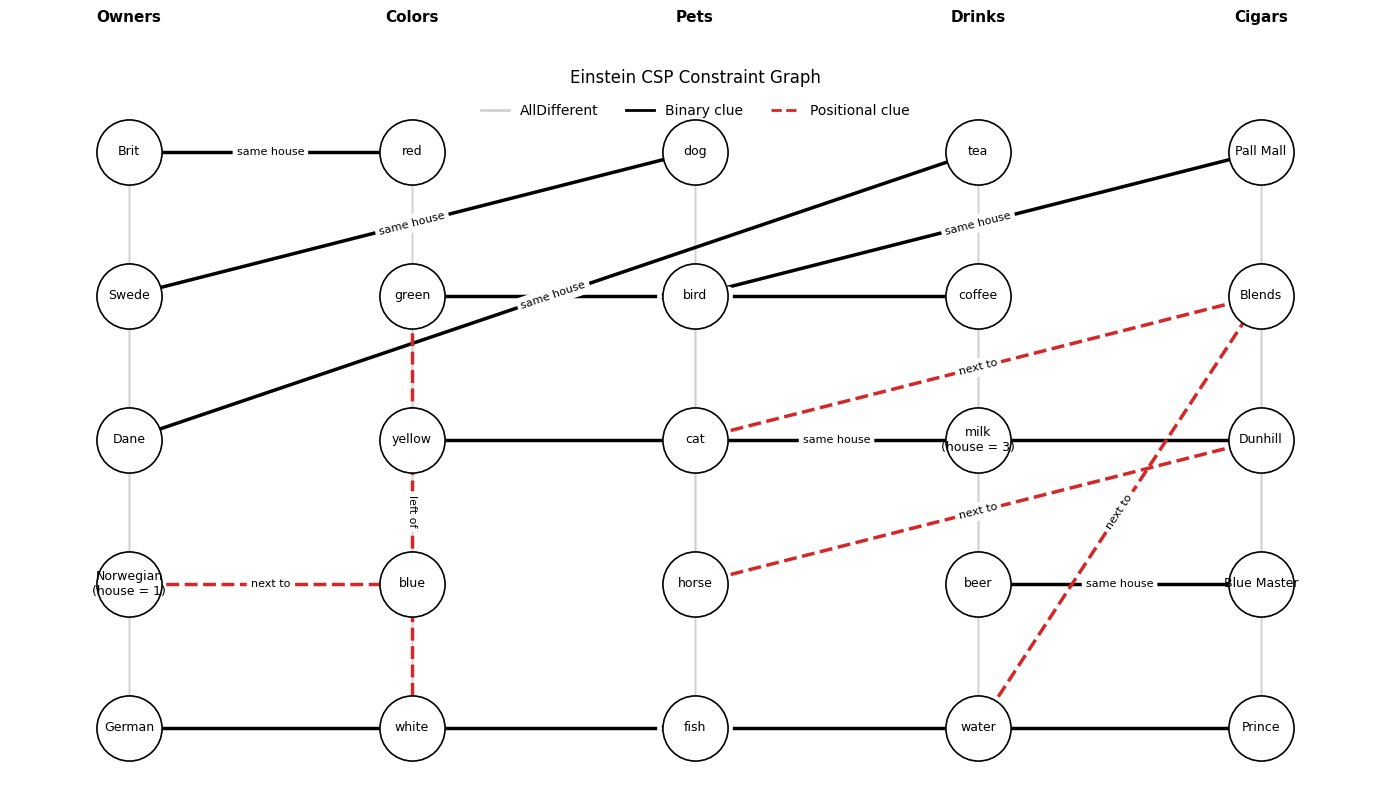

In [4]:
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
from matplotlib.lines import Line2D

all_nodes = owners + house_color + pets + drink + cigar

G = nx.Graph()
G.add_nodes_from(all_nodes)

# Clue edges
binary_edges = [
    ("Brit", "red", "binary"),
    ("Swede", "dog", "binary"),
    ("Dane", "tea", "binary"),
    ("green", "coffee", "binary"),
    ("Pall Mall", "bird", "binary"),
    ("yellow", "Dunhill", "binary"),
    ("Blue Master", "beer", "binary"),
    ("German", "Prince", "binary"),
]

positional_edges = [
    ("green", "white", "positional"),
    ("Blends", "cat", "positional"),
    ("horse", "Dunhill", "positional"),
    ("Norwegian", "blue", "positional"),
    ("Blends", "water", "positional"),
]

for u, v, kind in binary_edges + positional_edges:
    G.add_edge(u, v, kind=kind)

# AllDifferent edges within each category
groups = [owners, house_color, pets, drink, cigar]
for group in groups:
    for u, v in combinations(group, 2):
        if not G.has_edge(u, v):
            G.add_edge(u, v, kind="alldiff")

# Fixed layout
pos = {}

for i, node in enumerate(owners):
    pos[node] = (0, 4 - i)

for i, node in enumerate(house_color):
    pos[node] = (2.5, 4 - i)

for i, node in enumerate(pets):
    pos[node] = (5, 4 - i)

for i, node in enumerate(drink):
    pos[node] = (7.5, 4 - i)

for i, node in enumerate(cigar):
    pos[node] = (10, 4 - i)

# Put unary constraints inside node labels
labels = {node: node for node in G.nodes()}
labels["Norwegian"] = "Norwegian\n(house = 1)"
labels["milk"] = "milk\n(house = 3)"

plt.figure(figsize=(14, 8))

nx.draw_networkx_nodes(
    G, pos,
    node_color="white",
    edgecolors="black",
    node_size=2200,
    linewidths=1.2
)

nx.draw_networkx_labels(G, pos, labels=labels, font_size=9)

alldiff_edges = [(u, v) for u, v, d in G.edges(data=True) if d["kind"] == "alldiff"]
binary_only = [(u, v) for u, v, d in G.edges(data=True) if d["kind"] == "binary"]
positional_only = [(u, v) for u, v, d in G.edges(data=True) if d["kind"] == "positional"]

nx.draw_networkx_edges(
    G, pos,
    edgelist=alldiff_edges,
    edge_color="lightgray",
    width=1,
    alpha=0.7
)

nx.draw_networkx_edges(
    G, pos,
    edgelist=binary_only,
    edge_color="black",
    width=2.5
)

nx.draw_networkx_edges(
    G, pos,
    edgelist=positional_only,
    edge_color="tab:red",
    width=2.5,
    style="dashed"
)

edge_labels = {
    ("Brit", "red"): "same house",
    ("Swede", "dog"): "same house",
    ("Dane", "tea"): "same house",
    ("green", "coffee"): "same house",
    ("Pall Mall", "bird"): "same house",
    ("yellow", "Dunhill"): "same house",
    ("Blue Master", "beer"): "same house",
    ("German", "Prince"): "same house",
    ("green", "white"): "left of",
    ("Blends", "cat"): "next to",
    ("horse", "Dunhill"): "next to",
    ("Norwegian", "blue"): "next to",
    ("Blends", "water"): "next to",
}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.text(0, 4.9, "Owners", ha="center", fontsize=11, fontweight="bold")
plt.text(2.5, 4.9, "Colors", ha="center", fontsize=11, fontweight="bold")
plt.text(5, 4.9, "Pets", ha="center", fontsize=11, fontweight="bold")
plt.text(7.5, 4.9, "Drinks", ha="center", fontsize=11, fontweight="bold")
plt.text(10, 4.9, "Cigars", ha="center", fontsize=11, fontweight="bold")

legend = [
    Line2D([0], [0], color="lightgray", lw=2, label="AllDifferent"),
    Line2D([0], [0], color="black", lw=2, label="Binary clue"),
    Line2D([0], [0], color="tab:red", lw=2, linestyle="--", label="Positional clue"),
]
plt.legend(handles=legend, loc="upper center", ncol=3, frameon=False)

plt.title("Einstein CSP Constraint Graph")
plt.axis("off")
plt.tight_layout()
plt.show()

2. **Search Space Size**
- Without constraingts, there are $5^{25}$ permutations to search through because each of the 25 variables can take any of the 5 house positions.
- After adding `AllDifferent`, it shrinks each group to $5!$ permutations because we are now assuming one to one relationships
- Adding the 15 clues prunes the search space to 1 valid solution
3. **Constraint Propagation**
- AC-3 enforces arc consistently by removing invalid values from domains before assignments are made based on the constraints. This propagation is stronger than just forward checking after an assignment.
- It would start with applying the unary constraints that Norwegian is in position 1 and mik is in position 3
- Due to AllDifferent, other owners now cannot be 0 and other drinks cannot be 2
- Prune unsupported values based on the "next to" conditional for green and white domains
- Since 2 was removed from coffee and green is constrained by coffee, we can remove 2 from coffee too
- Remove all non-neighbor values in Blue based on constraint with Norwegian, which leaves us with 1.
- `AllDifferent` again prunes 1 from all the other domains
- propagate until we are left with only the unique solution

3. **Complexity**
- Pure backtracking is $O(d^n)$ because it may try many invalid assignments before discovering constraint conflicts.
- Constraint propagation has the same worst-case bound, but propagation such as AC-3 prunes domains early enough that it reduces the branching factor by a lot.
- The more constraints you add, the greater the propagation and reduction in branching factor

4. **Reflection**
- The puzzle has a unique solution because the clues are not independent. The constraints each remove a large number of possible permutation branches and greatly reduce the search space. I think of it in a metaphor such as road closures. If you close down enough routes, eventually you are only left with one route to take to your destination. Or in another perspective, only one destination possibility.
- The power of CSP methods is that we can turn a combinatorially huge problem into a very easy one by exploiting the structure of constraint propagation rather than using brute force via search methods such as graph search algorithms. In this of Einstein's Riddle, we don't even need to search.

# Q2 — Principal Component Analysis on MNIST  

## 35 points total

In this problem, you will implement **Principal Component Analysis (PCA)** from scratch using the MNIST dataset. You must not use the built-in PCA functions in scikit-learn. Instead, you will write the steps yourself using NumPy. Use at least **1000 samples** and ensure the data is class-balanced.  

You may download the dataset from either of the following sources:  
- Import directly into your notebook
- Alternative dataset links: [GTDLBench](https://git-disl.github.io/GTDLBench/datasets/mnist_datasets/), [Kaggle](https://www.kaggle.com/datasets/hojjatk/mnist-dataset), [Hugging Face](https://huggingface.co/datasets/ylecun/mnist)

---

## [15 points] Part A – Coding (Implementation)  

### Data Preparation  
- Load MNIST
- Select at least **1000 balanced samples**.  
- Flatten images into vectors and **standardize the data**.  

### PCA from Scratch  
- Compute the **covariance matrix**.  
- Find **eigenvalues** and **eigenvectors**.  
- Sort eigenvalues and project the data into the new space.  

### Variance Explained  
- Plot the **explained variance** (scree plot).  
- Determine how many principal components to retain.  

---

## [20 points] Part B – Analysis (Explanation)  

### Component Selection  
- Justify your choice of how many components to keep.  
- Discuss trade-offs between dimensionality reduction and information retention.  

### Visualization  
- Create at least **five distinct 2D scatter plots** of the data projected onto different pairs of principal components (e.g., PC1 vs. PC2, PC2 vs. PC3, etc.), coloring points by digit class.  
- Comment on what these plots reveal about **class separability** and **structure** in the data.  

### Interpretation  
- Explain why each step of PCA matters (**covariance, eigenvalues, variance explained**).  
- Discuss one **real-world application** where PCA would be useful.  


In [5]:
## Your code goes here
import numpy as np
from tensorflow.keras.datasets import mnist

# x_train are the 28x28 pixel images, y_train are the labels
# We don't need to load the x_test or y_test Numpy arrays
(x_train, y_train), _ = mnist.load_data()

I0000 00:00:1774161367.840940  226191 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774161366.670107  226191 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774161370.185458  226191 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [6]:
num_classes = 10
samples_per_class = 100

# Iterate to select balanced samples
# For balanced, we want an equal number of samples from each digit 0 to 9
selected_indices = []
for digit in range(num_classes):
  # Get the indexes of the first 100 matching samples for digit
  idx = np.where(y_train == digit)[0]
  chosen = np.random.choice(idx, samples_per_class, replace=False)
  selected_indices.extend(chosen)
selected_indices = np.array(selected_indices)

# Flatten
flat_images = x_train[selected_indices].reshape(-1,28*28).astype(np.float32)
labels = y_train[selected_indices]

# Shuffle
perm = np.random.permutation(len(labels))
flat_images, labels = flat_images[perm], labels[perm]

# Standardize the data
image_mean = np.mean(flat_images, axis=0)
img_std = np.std(flat_images, axis=0) + 1e-8  # avoid division by zero
img_stdzd = (flat_images - image_mean) / img_std

# Confirm that our dimensions are correct
print("Shape of standardized data:", img_stdzd.shape)
print("Shape of labels:", labels.shape)
print("Class distribution:", np.bincount(labels))

Shape of standardized data: (1000, 784)
Shape of labels: (1000,)
Class distribution: [100 100 100 100 100 100 100 100 100 100]


In [7]:

# Compute the covariance matrix
cov_matrix = np.cov(img_stdzd, rowvar=False)
print("Covariance matrix shape:", cov_matrix.shape)

Covariance matrix shape: (784, 784)


In [8]:
eigen_values, eigen_vectors = np.linalg.eigh(cov_matrix)
sorted_index = np.argsort(eigen_values)[::-1]
sorted_eigen_values = eigen_values[sorted_index]
# avoid values that are just 0 for space when printing
sorted_eigen_values = sorted_eigen_values[sorted_eigen_values > 0]
sorted_eigen_vectors = eigen_vectors[:, sorted_index]

# Explained variance ratio
explained_var_ratio = sorted_eigen_values / np.sum(sorted_eigen_values)

# Shoot for 95% of total variance
cum_evr = np.cumsum(explained_var_ratio)
# Find index where cumulative explained variance first reaches at least 95%
var_95 = np.argmax(cum_evr >= 0.95) + 1
print(f"Need # of PCs for 95% var: {var_95}")

# Use dot product to compress into variance minimum dimensions
img_compressed = np.dot(img_stdzd, sorted_eigen_vectors[:, :var_95])

Need # of PCs for 95% var: 189


In [9]:
# Scree plotting code from PCA walkthrough from module 7
import plotly.graph_objects as go

fig = go.Figure()
# Bar trace for individual explained variance
components = np.arange(1, len(explained_var_ratio) + 1)

fig.add_trace(go.Bar(
    x=components,
    y=explained_var_ratio,
    name='Explained Variance Ratio',
    marker=dict(color='rgba(31, 119, 180, 0.7)')
))

# Line trace for cumulative variance
fig.add_trace(go.Scatter(
    x=components,
    y=cum_evr,
    mode='lines+markers',
    name='Cumulative Explained Variance',
    line=dict(color='firebrick', width=3)
))

# 5) Figure layout
fig.update_layout(
    title='Scree Plot — PCA on MNIST (Standardized)',
    xaxis_title='Principal Component',
    yaxis_title='Proportion of Variance Explained',
    legend=dict(x=0.7, y=0.1),
    template='plotly_white'
)

fig.show()


### Analysis


For question 2, PCA worked pretty well on this balanced MNIST subset. The scree plot shows that the first few components carry much more variance than later ones, and then the curve starts to level out. That means most of the important structure in the images is captured early, while later components mostly add small details.

Using the 95 percent variance target gave a compressed version of the data with way fewer dimensions than 784. So PCA gives strong dimensionality reduction while still keeping most of the information. The tradeoff is that this keeps global variance, not class labels directly, so some digit-specific details can still be lost even when total variance is high.


In [10]:
# Q2 analysis helper metrics
print("Original feature count:", img_stdzd.shape[1])
print("Samples used:", img_stdzd.shape[0])
print("PCs needed for 95% variance:", var_95)
print("Compression ratio (new/original):", round(var_95 / img_stdzd.shape[1], 4))

top_k = 10
print(f"Variance explained by first {top_k} PCs:", round(float(np.sum(explained_var_ratio[:top_k])), 4))
print("Cumulative variance at 95% cutoff:", round(float(cum_evr[var_95 - 1]), 4))

#reconstruction error check
recon = img_compressed @ sorted_eigen_vectors[:, :var_95].T
mse = np.mean((img_stdzd - recon) ** 2)
print("Reconstruction MSE in standardized space:", round(float(mse), 6))



Original feature count: 784
Samples used: 1000
PCs needed for 95% variance: 189
Compression ratio (new/original): 0.2411
Variance explained by first 10 PCs: 0.3392
Cumulative variance at 95% cutoff: 0.9504
Reconstruction MSE in standardized space: 0.038754


In [11]:
# Q2 visualization: five 2D PCA scatter plots colored by digit class
import pandas as pd
import plotly.express as px

# Project data onto first 6 principal components so we can create multiple pairs
pca_scores = img_stdzd @ sorted_eigen_vectors[:, :6]

pc_df = pd.DataFrame(
    pca_scores,
    columns=[f"PC{i}" for i in range(1, 7)]
)
pc_df["digit"] = labels.astype(str)

pairs = [("PC1", "PC2"), ("PC2", "PC3"), ("PC3", "PC4"), ("PC1", "PC3"), ("PC1", "PC5")]

for x_pc, y_pc in pairs:
    fig = px.scatter(
        pc_df,
        x=x_pc,
        y=y_pc,
        color="digit",
        opacity=0.65,
        title=f"MNIST PCA Projection: {x_pc} vs {y_pc}",
        labels={"digit": "Digit Class"},
        width=900,
        height=600
    )
    fig.update_traces(marker=dict(size=6))
    fig.update_layout(template="plotly_white")
    fig.show()



From the five scatter plots, the classes are not fully separated, but there is still visible structure. In PC1 vs PC2, some digits form looser groups while others overlap heavily. When moving to pairs like PC2 vs PC3 and PC3 vs PC4, a few classes spread out in different directions, which shows that separation information is distributed across multiple components instead of only the first two.

PC1 vs PC5 usually looks noisier than earlier pairs, which matches the idea that later PCs explain less variance. Even so, those later components can still help separate certain confusing digit pairs a little. Overall, PCA gives partial class separability and a meaningful low-dimensional structure, but it does not perfectly split all classes by itself.


Covariance matters because PCA starts by measuring how pixel features vary together. If two pixel directions change together, covariance captures that relationship. Eigenvalues and eigenvectors matter because they define the new axes: eigenvectors are the component directions, and eigenvalues tell how much variance each direction keeps. Variance explained matters because it gives a practical way to choose how many components to keep, so we can balance compression and information retention instead of guessing.

One real-world use case is face recognition or face clustering from images. Raw image vectors are very high-dimensional, so PCA can reduce noise and size first, making downstream training and storage much easier while preserving most useful visual information.


# Q3 — Training Models with Gradient Descent and Its Variants  

## 30 points total

In this problem, you will get hands-on experience with gradient-based optimization algorithms. You will first apply them to a simple convex model (logistic regression) and then explore their behavior on a small non-convex model (neural network). The goal is to understand how and why these algorithms behave differently in practice.

---

## [10 points] Part A – Learning to separate two classes  

In this part, you will implement gradient descent from scratch to understand how it learns and converges.

### Dataset  

```python
import numpy as np

# Simple linearly separable data
X = np.array([[0,1],[1,2],[2,1],[3,2],[3,4],[4,3],[5,4],[6,5]])
y = np.array([0,0,0,0,1,1,1,1])  # 0 = Class A, 1 = Class B

```

### Model
- Implement logistic regression using batch gradient descent (use all data to compute the gradient each step).
- Start all parameters $(w, b)$ = 0, learning rate = 0.1.
- Run 1000 updates and plot the loss curve (loss vs. iterations).

### Visualization and Interpretation
- Draw a scatter plot showing the decision boundary learned by your model.
- Provide interpretation of your plot(s), such as
    - Does the loss steadily decrease?
    - How does learning rate affect stability?


## [10 points] Part B – Comparing how fast models learn  

In this part, you will use gradient descent as a baseline and compare it to other optimizers.

### Dataset and Model

- Use the same dataset and loss function as in Part A.
- Train the same model using three optimizers
    - Batch Gradient Descent (GD)
    - Stochastic Gradient Descent (SGD)
    - Adam
- Run each for 20 epochs.

### Visualization and Interpreation
- Plot all three loss curves on one graph.
- Provide interpretation of your plot(s), such as convergence speed, stability, etc.


## [10 points] Part C - Non-Convex Terrain

In this part, you will explore how optimization behaves in non-convex landscapes, where initialization matters.

### Model

- Build and train a tiny neural network, with its architecture as \
Input -> Hidden Layer (2 neurons, ReLU) -> Output (Sigmoid)
- Train the nework using Adam on the same dataset as in Part A.
- Run the training three times with different random weight initializations.


### Visualization and Interpreation
- Plot the loss curve for each run
- Discuss your results and plots, for example,
    - Do all runs end at the same loss value?
    - Why might some runs get "stuck" higher?
    - What does this show about challenges of non-convex optimization?











Final theta: [-5.7339  0.5387  1.6591]
Initial Cost: 0.6232
Final Cost: 0.1134
Predicted Probabilities: [0.0167 0.1327 0.0475 0.3101 0.9254 0.8019 0.9733 0.997 ]
Predicted Classes: [0 0 0 0 1 1 1 1]
Training Accuracy: 1.0


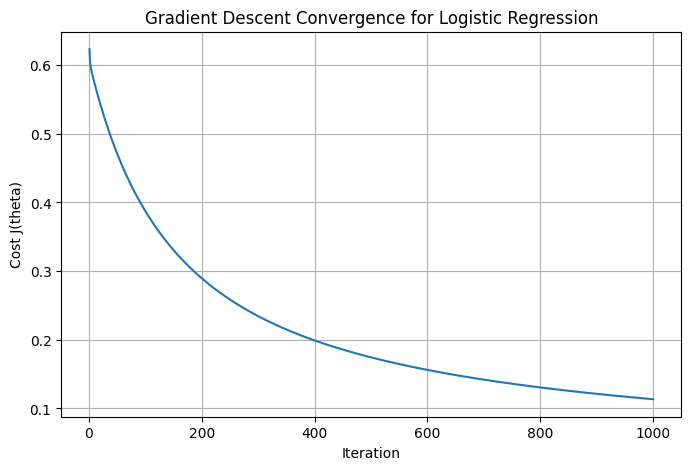

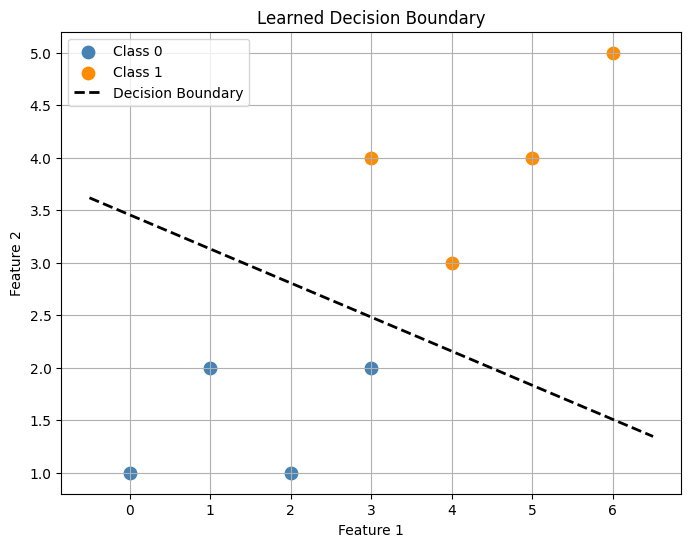

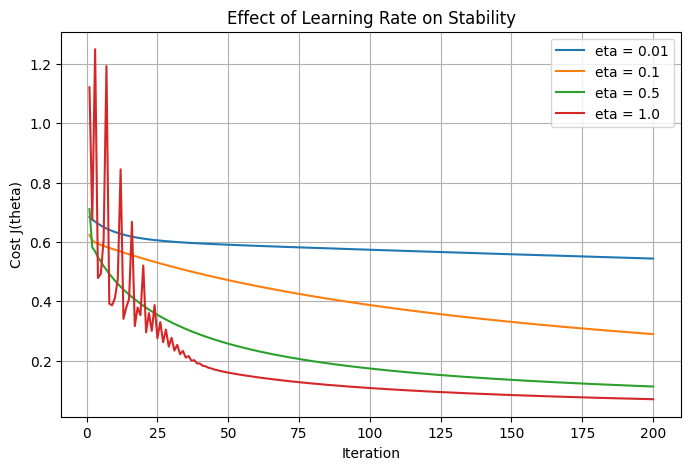

In [12]:
# Part A
#  Using code fromthe Module 8 logistic regression and convergence examples.

import numpy as np
import matplotlib.pyplot as plt

# Dataset: binary classification
X = np.array([[0,1],[1,2],[2,1],[3,2],[3,4],[4,3],[5,4],[6,5]], dtype=float)
y = np.array([0,0,0,0,1,1,1,1], dtype=float)
m = len(y)

# Add bias term (column of 1s)
X_b = np.c_[np.ones(m), X]   # shape (m, 3)

# Initialize parameters
theta_init = np.zeros(X_b.shape[1])
eta = 0.1
iterations = 1000


def sigmoid(z):
    """Sigmoid activation function."""
    return 1 / (1 + np.exp(-z))


def compute_cost(X_b, y, theta):
    """Binary Cross-Entropy (Log Loss)."""
    z = X_b.dot(theta)
    h = sigmoid(z)
    epsilon = 1e-8  # to avoid log(0)
    cost = (-1 / len(y)) * np.sum(y * np.log(h + epsilon) + (1 - y) * np.log(1 - h + epsilon))
    return cost


def compute_gradient(X_b, y, theta):
    """Compute gradient of the logistic cost function."""
    z = X_b.dot(theta)
    h = sigmoid(z)
    grad = (1 / len(y)) * X_b.T.dot(h - y)
    return grad


def batch_gradient_descent(X_b, y, theta_init, eta, iterations):
    theta = theta_init.copy()
    cost_history = []
    for t in range(iterations):
        grad = compute_gradient(X_b, y, theta)
        theta -= eta * grad
        cost_history.append(compute_cost(X_b, y, theta))
    return theta, cost_history


# Train the model using batch gradient descent
theta, cost_history = batch_gradient_descent(X_b, y, theta_init, eta, iterations)

# Prediction and thresholding
z = X_b.dot(theta)
predictions = sigmoid(z)
predicted_classes = (predictions >= 0.5).astype(int)
accuracy = np.mean(predicted_classes == y)

print('Final theta:', np.round(theta, 4))
print('Initial Cost:', round(cost_history[0], 4))
print('Final Cost:', round(cost_history[-1], 4))
print('Predicted Probabilities:', np.round(predictions, 4))
print('Predicted Classes:', predicted_classes)
print('Training Accuracy:', round(accuracy, 4))

# loss curve for the required learning rate (eta = 0.1)
plt.figure(figsize=(8, 5))
plt.plot(range(1, iterations + 1), cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost J(theta)')
plt.title('Gradient Descent Convergence for Logistic Regression')
plt.grid(True)
plt.show()

# scatter plot with learned decision boundary
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], color='steelblue', s=80, label='Class 0')
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='darkorange', s=80, label='Class 1')

# The learned boundary for logistic regression happens where the model is equally split
# between the two classes, meaning p(y=1|x) = 0.5 since this is binary classification.
# Since sigmoid(0) = 0.5, that occurs when theta0 + theta1*x1 + theta2*x2 = 0 
# (theta is learned vector of weights)

# Create some spaces across x-axis between the min and max points
x1_values = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 200)

# solve theta0 + theta1*x1 + theta2*x2 = 0 for x2:
# x2 = -(theta0 + theta1*x1) / theta2
# This gives the matching vertical coordinate for each x1 point on the boundary.
# Basically solving for equation of a line
if abs(theta[2]) > 1e-8: # guard /0 so computer doesn't blow up
    x2_values = -(theta[0] + theta[1] * x1_values) / theta[2]
    plt.plot(x1_values, x2_values, 'k--', linewidth=2, label='Decision Boundary')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Learned Decision Boundary')
plt.legend()
plt.grid(True)
plt.show()

# small learning-rate comparison for interpretation
learning_rates = [0.01, 0.1, 0.5, 1.0]
plt.figure(figsize=(8, 5))
for lr in learning_rates:
    theta_lr, lr_cost_history = batch_gradient_descent(X_b, y, theta_init, lr, 200)
    plt.plot(range(1, 201), lr_cost_history, label=f'eta = {lr}')

plt.xlabel('Iteration')
plt.ylabel('Cost J(theta)')
plt.title('Effect of Learning Rate on Stability')
plt.legend()
plt.grid(True)
plt.show()


### Analysis

- With the required learning rate of `0.1`, the loss decreases from about `0.6232` to `0.1134` over 1000 updates, so the optimization is steady and convergent.
- The decision boundary cleanly separates the two groups in the scatter plot, and the trained model classifies all 8 training points correctly.
- The learning-rate comparison shows the usual tradeoff: `0.01` is stable but slow, `0.1` is stable and faster, `0.5` converges faster on this dataset, and `1.0` becomes less stable because the loss oscillates early before settling.
- The batch gradient descent performed as expected based on the lectures notes and textbook analysis. Too high a learning rate and the gradient will oscillate back and forth, reducing stability in early training runs.

Final GD Cost: 0.5438
Final SGD Cost: 0.3211
Final Adam Cost: 0.3603


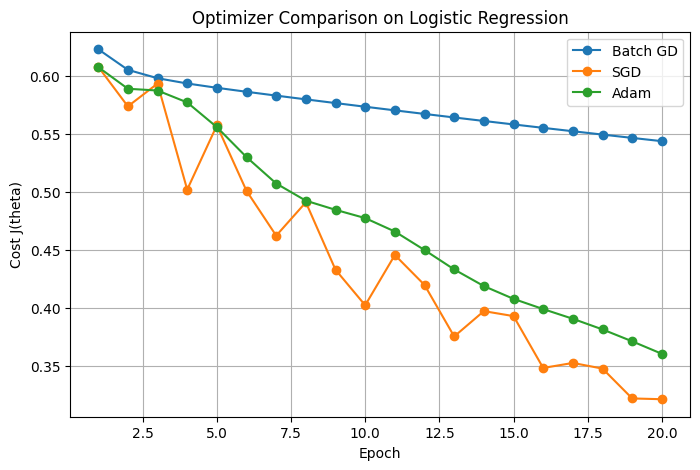

In [13]:
# Part B

def stochastic_gradient_descent_logistic(X_b, y, theta_init, eta, epochs, seed=42):
    theta = theta_init.copy()
    cost_history = []
    rng = np.random.default_rng(seed)

    for epoch in range(epochs):
        shuffled_indices = rng.permutation(len(y))
        for idx in shuffled_indices:
            xi = X_b[idx:idx + 1]
            yi = y[idx:idx + 1]

            # Same logistic-loss idea as Part A, but now update after one sample.
            z = xi.dot(theta)
            h = sigmoid(z)
            grad = xi.T.dot(h - yi)
            theta -= eta * grad

        cost_history.append(compute_cost(X_b, y, theta))

    return theta, cost_history

# Beta1 for moving avg of grad, beta2 for moving avg of squared grad
def adam_logistic(X_b, y, theta_init, eta, epochs, beta1=0.9, beta2=0.999, eps=1e-8):
    theta = theta_init.copy()
    m_t = np.zeros_like(theta)
    v_t = np.zeros_like(theta)
    cost_history = []

    for t in range(1, epochs + 1):
        grad = compute_gradient(X_b, y, theta)

        # Adam keeps moving averages of the gradient and squared gradient.
        m_t = beta1 * m_t + (1 - beta1) * grad
        v_t = beta2 * v_t + (1 - beta2) * (grad ** 2)

        m_hat = m_t / (1 - beta1 ** t)
        v_hat = v_t / (1 - beta2 ** t)

        theta -= eta * m_hat / (np.sqrt(v_hat) + eps)
        cost_history.append(compute_cost(X_b, y, theta))

    return theta, cost_history


epochs = 20
eta_part_b = 0.1

# For batch gd from part A, one full dataset update is one epoch here.
gd_theta, gd_cost_history = batch_gradient_descent(X_b, y, theta_init, eta_part_b, epochs)
sgd_theta, sgd_cost_history = stochastic_gradient_descent_logistic(X_b, y, theta_init, eta_part_b, epochs)
adam_theta, adam_cost_history = adam_logistic(X_b, y, theta_init, eta_part_b, epochs)

print('Final GD Cost:', round(gd_cost_history[-1], 4))
print('Final SGD Cost:', round(sgd_cost_history[-1], 4))
print('Final Adam Cost:', round(adam_cost_history[-1], 4))

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), gd_cost_history, marker='o', label='Batch GD')
plt.plot(range(1, epochs + 1), sgd_cost_history, marker='o', label='SGD')
plt.plot(range(1, epochs + 1), adam_cost_history, marker='o', label='Adam')
plt.xlabel('Epoch')
plt.ylabel('Cost J(theta)')
plt.title('Optimizer Comparison on Logistic Regression')
plt.legend()
plt.grid(True)
plt.show()


### Analysis

- Over 20 epochs, all three optimizers reduce the logistic loss, but they do so at different speeds and with different levels of smoothness.
- In this run, Batch GD is the smoothest but also the slowest, ending around `0.5438`.
- SGD reaches the lowest final loss here, about `0.3211`, but its curve is noisier because each update uses one training example at a time.
- Adam also converges faster than Batch GD and is more stable than SGD, ending around `0.3603` on this dataset.
- On this small problem, SGD and Adam both learn faster than plain Batch GD, but SGD shows the clearest tradeoff between speed and stability. Makes sense why SGD would be something you primarily use in real time applications like sensor signal processing due to the inherent noisiness.


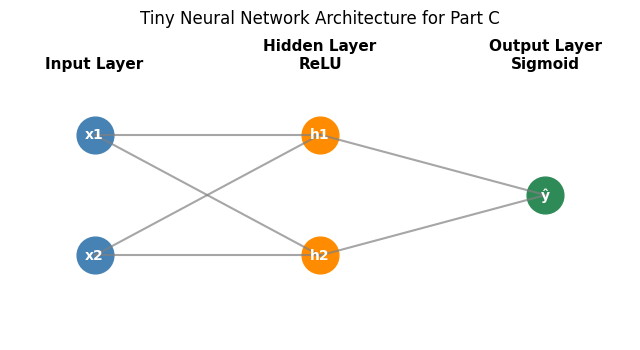

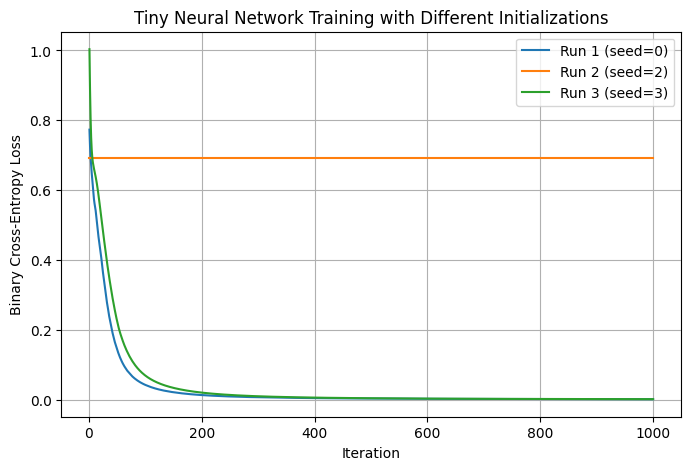

Run 1 | seed=0 | final loss=0.0009 | accuracy=1.0000
Run 2 | seed=2 | final loss=0.6931 | accuracy=0.5000
Run 3 | seed=3 | final loss=0.0011 | accuracy=1.0000


In [14]:
# Part C

# I used the following online resource from Stanford to aid in the implementation
# https://cs231n.github.io/neural-networks-case-study/

# Small diagram of the exact network used below: 2 inputs -> 2 hidden ReLU units -> 1 sigmoid output.
plt.figure(figsize=(8, 4))
ax = plt.gca()

input_nodes = [(0, 2.5), (0, 1.5)]
hidden_nodes = [(2, 2.5), (2, 1.5)]
output_nodes = [(4, 2.0)]

for x1, y1 in input_nodes:
    for x2, y2 in hidden_nodes:
        ax.plot([x1, x2], [y1, y2], color='gray', alpha=0.7)

for x1, y1 in hidden_nodes:
    for x2, y2 in output_nodes:
        ax.plot([x1, x2], [y1, y2], color='gray', alpha=0.7)

for x, y_val in input_nodes:
    ax.scatter(x, y_val, s=700, color='steelblue')
for x, y_val in hidden_nodes:
    ax.scatter(x, y_val, s=700, color='darkorange')
for x, y_val in output_nodes:
    ax.scatter(x, y_val, s=700, color='seagreen')

ax.text(0, 3.05, 'Input Layer', ha='center', fontsize=11, fontweight='bold')
ax.text(2, 3.05, 'Hidden Layer\nReLU', ha='center', fontsize=11, fontweight='bold')
ax.text(4, 3.05, 'Output Layer\nSigmoid', ha='center', fontsize=11, fontweight='bold')

ax.text(0, 2.5, 'x1', ha='center', va='center', color='white', fontweight='bold')
ax.text(0, 1.5, 'x2', ha='center', va='center', color='white', fontweight='bold')
ax.text(2, 2.5, 'h1', ha='center', va='center', color='white', fontweight='bold')
ax.text(2, 1.5, 'h2', ha='center', va='center', color='white', fontweight='bold')
ax.text(4, 2.0, 'ŷ', ha='center', va='center', color='white', fontweight='bold')

ax.set_xlim(-0.75, 4.75)
ax.set_ylim(0.8, 3.35)
ax.axis('off')
plt.title('Tiny Neural Network Architecture for Part C')
plt.show()

def relu(x):
    return np.maximum(0, x)


def relu_derivative(x):
    return (x > 0).astype(float)


def compute_binary_cross_entropy(y_true, y_pred):
    epsilon = 1e-8
    return -np.mean(y_true * np.log(y_pred + epsilon) + (1 - y_true) * np.log(1 - y_pred + epsilon))


def train_tiny_network(X, y, seed, epochs=1000, eta=0.05, beta1=0.9, beta2=0.999, eps=1e-8, scale=0.5):
    # Use a different random seed for each run so the network starts from a different place.
    rng = np.random.default_rng(seed)

    # Architecture: Input(2) -> Hidden(2, ReLU) -> Output(1, Sigmoid)

    # Weights for input to hiden layer
    W1 = rng.normal(0, scale, size=(2, 2))
    b1 = np.zeros((1, 2))

    # Weights for hidden to output layer
    W2 = rng.normal(0, scale, size=(2, 1))
    b2 = np.zeros((1, 1))

    # Keep all trainable parameters together so Adam can update them in one loop.
    params = [W1, b1, W2, b2]
    # Adam stores two running summaries for each parameter:
    # m_params tracks the average gradient, v_params tracks the average squared gradient.
    m_params = [np.zeros_like(p) for p in params]
    v_params = [np.zeros_like(p) for p in params]
    loss_history = []

    for t in range(1, epochs + 1):
        # Forward pass:
        # 1. Multiply the inputs by the hidden-layer weights and add the hidden bias.
        Z1 = X.dot(W1) + b1
        # 2. Apply ReLU so negative hidden activations become 0.
        # A1 becomes 8x2 matrix of hidden activations for each sample.
        A1 = relu(Z1)
        # 3. Send the hidden activations to the output neuron.
        Z2 = A1.dot(W2) + b2
        # 4. Apply sigmoid so the output becomes a probability for class 1.
        A2 = sigmoid(Z2)

        # Measure how wrong the current predictions are and store that value.
        loss_history.append(compute_binary_cross_entropy(y, A2))

        # Backpropagation:
        # Start at the output layer and compute how much the predictions differ from the labels.
        # dZ2 becomes 8x1 matrix of output errors for each sample.
        dZ2 = A2 - y
        # Use that output-layer error to compute gradients for W2 and b2.
        # Take the loss L and differentite it with respect to every entry in W2
        # Math...

        # ∂L/∂w1 = ∂L/∂z2 * ∂z2/∂w1

        # z2 = a1_1*w1 + a1_2*w2 + b2

        # ∂z2/∂w1 = a1_1

        # ∂L/∂w1 = a1_1 * dZ2
        # ∂L/∂w2 = a1_2 * dZ2

        # [[a1_1 * dZ2],
        # [a1_2 * dZ2]]

        dW2 = (A1.T.dot(dZ2)) / len(y)
        db2 = np.mean(dZ2, axis=0, keepdims=True)

        # Push the error backward into the hidden layer.
        dA1 = dZ2.dot(W2.T)
        # ReLU derivative blocks gradient flow where the hidden unit was inactive.
        dZ1 = dA1 * relu_derivative(Z1)
        # Compute gradients for the first layer weights and biases.
        dW1 = (X.T.dot(dZ1)) / len(y)
        db1 = np.mean(dZ1, axis=0, keepdims=True)

        grads = [dW1, db1, dW2, db2]

        # This is the step that actually moves the weights and biases to reduce the loss.
        for i in range(len(params)):
            m_params[i] = beta1 * m_params[i] + (1 - beta1) * grads[i]
            v_params[i] = beta2 * v_params[i] + (1 - beta2) * (grads[i] ** 2)

            m_hat = m_params[i] / (1 - beta1 ** t)
            v_hat = v_params[i] / (1 - beta2 ** t)

            params[i] -= eta * m_hat / (np.sqrt(v_hat) + eps)

        W1, b1, W2, b2 = params

    # Run one last forward pass after training so we can summarize final loss behavior.
    Z1 = X.dot(W1) + b1
    A1 = relu(Z1)
    Z2 = A1.dot(W2) + b2
    A2 = sigmoid(Z2)
    predicted_classes = (A2 >= 0.5).astype(int)
    accuracy = np.mean(predicted_classes == y)

    return loss_history, accuracy


y_nn = y.reshape(-1, 1)
seeds = [0, 2, 3]
run_results = []

plt.figure(figsize=(8, 5))
for run_number, seed in enumerate(seeds, start=1):
    loss_history, accuracy = train_tiny_network(X, y_nn, seed=seed)
    run_results.append((run_number, seed, loss_history[-1], accuracy))
    plt.plot(range(1, len(loss_history) + 1), loss_history, label=f'Run {run_number} (seed={seed})')

plt.xlabel('Iteration')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Tiny Neural Network Training with Different Initializations')
plt.legend()
plt.grid(True)
plt.show()

for run_number, seed, final_loss, accuracy in run_results:
    print(f'Run {run_number} | seed={seed} | final loss={final_loss:.4f} | accuracy={accuracy:.4f}')


### Analysis

- The three runs do not end at exactly the same loss, even though they use the same dataset and optimizer. In this setup, two runs converge to a very small loss, while one run stays near `0.6931`, which is close to random-guess performance for binary classification.
- This difference comes from the random initialization of the network weights. Because the network uses a hidden ReLU layer, some initializations can leave hidden units inactive, which makes optimization much harder.
- That behavior illustrates the main challenge of non-convex optimization: the training path depends on where the model starts, so different runs can reach different solutions.
- Compared with logistic regression in Parts A and B, the neural network is more flexible, but it is also less predictable because the loss surface has more complicated geometry.
